<a href="https://colab.research.google.com/github/grkenney/WinSPIRE-HLC-Python/blob/main/Notebooks/Keys/Day_3.2_Line_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Line Graphs

Line graphs are often used to show the change in a single variable over time. In this lesson we're going to learn how to make and customize line graphs using `seaborn`.

In [67]:
# import seaborn and nickname it sns
import seaborn as sns

# import pandas and nickname it pd
import pandas as pd

# import matplotlib.pyplot and nickname it plt
import matplotlib.pyplot as plt

# set up inline figures
%matplotlib inline

Next, let's load in our data set.

In [64]:
url = 'https://github.com/grkenney/WinSPIRE-HLC-Python/raw/refs/heads/main/data/qPCR_data_cleaned.csv'
df = pd.read_csv(url)
df.head()

,sample_id,treatment_group,well,timepoint,MKI67,MTOR,BAX,IRF1
0,657317,Control,1,0,1.004377,1.379025,0.799135,0.672194
1,657317,Control,2,8,0.894172,1.345400,0.956142,0.756379
2,657317,Control,3,16,0.679445,1.098444,1.209928,0.050000
3,657317,Control,4,24,0.721341,1.063588,1.586136,0.643022
4,407401,Control,5,0,1.091682,0.843497,0.354864,0.489234


Remember how we wanted to exclude that data point where `MTOR` was > 9. Let's subset our data frame again here before we get into plotting.

In [65]:
# subset df to rows where MTOR < 9
df = df.query("MTOR < 9")

## Expression of one gene

Let's make our first line graph using the `lineplot` function from `seaborn`.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='BAX'>

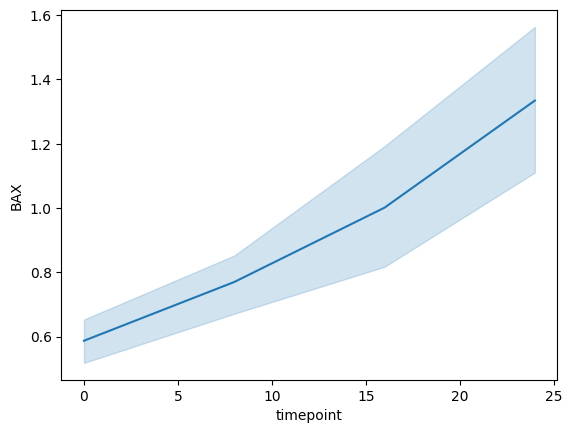

In [14]:
# line graph of BAX signal over time
sns.lineplot(x="timepoint", y="BAX", data=df)

Can you guess why this plot returns both a line and a shaded area?

If we look back at our data, we can see that we have measurements for several samples at each `timepoint`, meaning that each `timepoint` has not just one, but multiple corresponding `BAX` expression values. When this happens, `seaborn` knows to take the **mean** of the data (shown as the single line), but also report the **spread** of the data (here, the *confidence interval*, shown in the shaded band) to give us a sense of how similar/different the expression is across our samples.

But what if we wanted to visualize the *difference* between the expression in the Treatment vs. Control group? `seaborn` lets us do this really simply with the `hue` parameter:

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='BAX'>

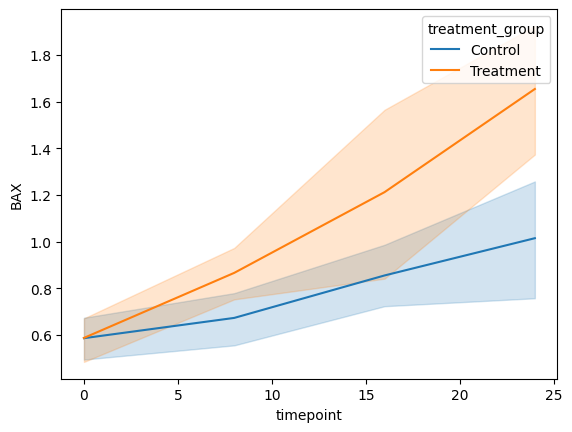

In [15]:
# line graph of BAX signal over time and color by treatment_group
sns.lineplot(x="timepoint", y="BAX", data=df, hue = "treatment_group")

Based on this plot what can we infer about the response of `BAX` to each treatment? By separating the signal in the two treatments we can see that the expression response is not as strong in the Control group (blue) as it is in the Treatment group (blue). 

What if we now wanted to visualize the same separation without using color? We could use another parameter - `style`.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='BAX'>

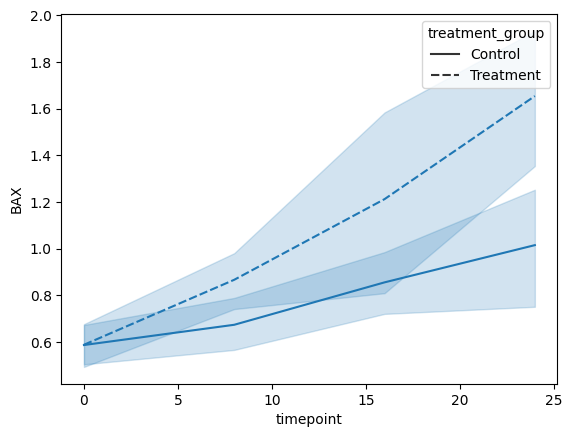

In [16]:
sns.lineplot(x="timepoint", y="BAX", data=df, style = "treatment_group")

**Exercise:** 
1. Plot `IRF1` expression over time with a line graph. *(hint: there should be a single line on this plot)*
3. Change the color of the `IRF1` line graph to your favorite color. *(hint: there should be a single line on this plot)*
4. Separate the line graph of `IRF1` expression by `treatment_group` with both `hue` and `style`. *(hint: there should be two lines on this plot)*
5. Change the colors of the separated line graph using two hexcodes. *(hint: there should be two lines on this plot)*
    * [Hexcode Color Picker](https://htmlcolorcodes.com/color-picker/)

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='IRF1'>

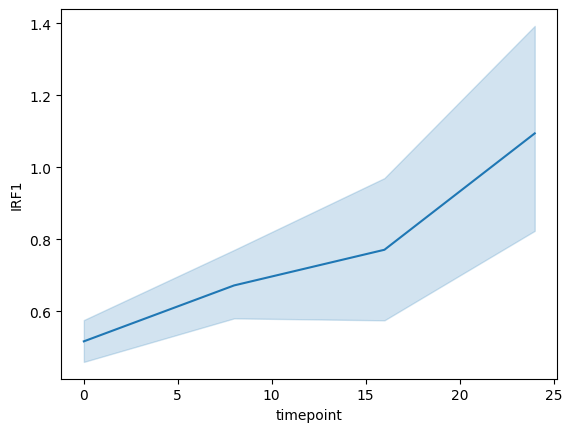

In [17]:
# line graph of IRF1 expression over time
sns.lineplot(x="timepoint", y="IRF1", data=df)

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='IRF1'>

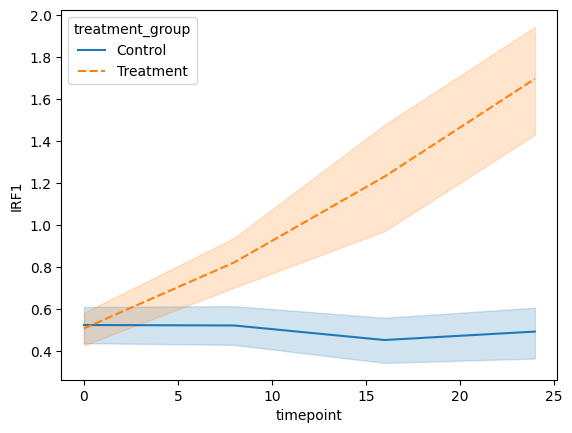

In [18]:
# line graph of IRF1 expression over time in your favorite color
sns.lineplot(x="timepoint", y="IRF1", data=df, hue = "treatment_group", style = "treatment_group")

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='IRF1'>

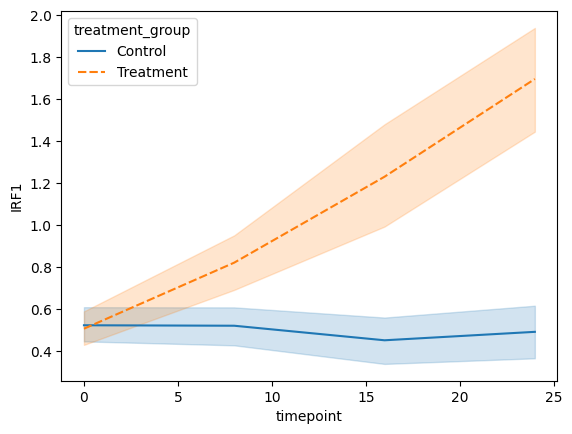

In [19]:
# line graph of IRF1 expression over time separated by treatment_group using both hue and style
sns.lineplot(x="timepoint", y="IRF1", data=df, hue = "treatment_group", style = "treatment_group")

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='IRF1'>

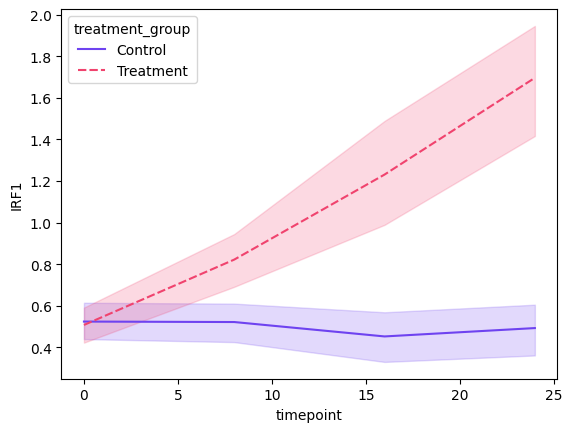

In [21]:
# line graph of IRF1 expression over time separated by treatment_group using both hue and style using hexcode colors
sns.lineplot(x="timepoint", y="IRF1", data=df, hue = "treatment_group", style = "treatment_group", palette = ["#6E43F0", "#F0436E"])

## Expression of multiple genes

So far, we've learned how to plot the expression of a single gene, but what if we want to visualize expression of all of our genes together.

Let's try doing this the same way we did with histograms in the last lesson to plot the expression of `BAX` and `MKI67` together.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

<Axes: xlabel='timepoint', ylabel='BAX'>

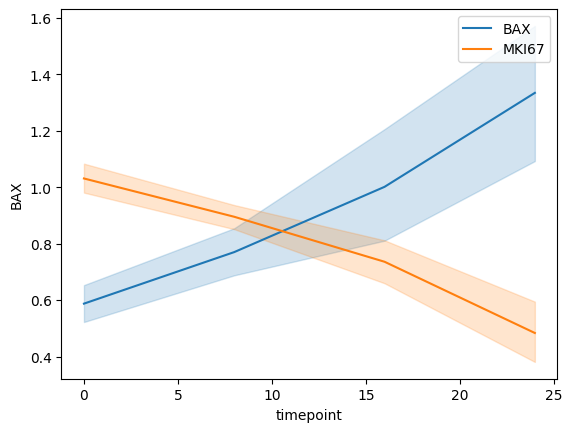

In [58]:
sns.lineplot(x="timepoint", y="BAX", data=df, label = "BAX")
sns.lineplot(x="timepoint", y="MKI67", data=df, label = "MKI67")

That worked! We now have two lines, one for each gene.

Now let's say we want to plot all of the genes together. We could type out a plot for each gene individually, but that might get a little tedious. Especially if we are working with a larger data set with many more genes than we have here.

Let's see if we can make this more efficient and plot all of our genes together in a single plot with a single line of code.

To do this, we have to reformat our data from it's current "wide" format to a "long" format. We can do this with a method called `melt`.

In [25]:
# transform df from wide to long format using melt and save in a variable called df_long
# use sample_id, treatment_group, well, and timepoint as id variables
# store the gene names to a column called gene
# store the expression values in a column called expression
df_long = df.melt(id_vars=['sample_id', 'treatment_group', 'well', 'timepoint'], 
                  var_name='gene', value_name='expression')

In [26]:
# view the first few lines of df_long
df_long.head()

,sample_id,treatment_group,well,timepoint,gene,expression
0,657317,Control,1,0,MKI67,1.004377
1,657317,Control,2,8,MKI67,0.894172
2,657317,Control,3,16,MKI67,0.679445
3,657317,Control,4,24,MKI67,0.721341
4,407401,Control,5,0,MKI67,1.091682


We say that this data is in "long" format because each data point now has it's own line. Now let's try to plot all of our genes in a single line of code, separating genes by color (hue).

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='expression'>

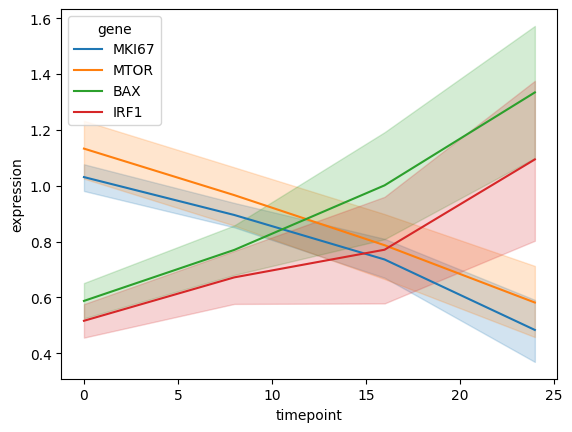

In [59]:
# line graph of expression over time, separated by gene using hue
sns.lineplot(x="timepoint", y="expression", data=df_long, hue = "gene")

Great! Now we can see how expression of each gene changes over time, but we still want to know how these changes differ with treatment group. So, let's also separate our plot by `treatment_group` with line style (`style`).

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='timepoint', ylabel='expression'>

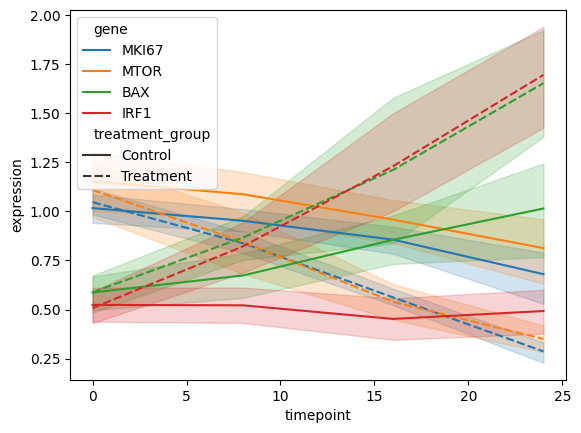

In [60]:
sns.lineplot(x="timepoint", y="expression", data=df_long, hue = "gene", style = "treatment_group")

That worked. But there's a lot going on here. It might be easier if we instead plot each gene in it's own plot area. We can separate plot areas by columns in our data frame using `seaborn`'s `relplot` function. 

We still specify `x`, `y`, `data` and `style` the same. We will also give 2 new parameters: `col` which is the column we want to split the plots on and `kind` which is the kind of plot we want.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

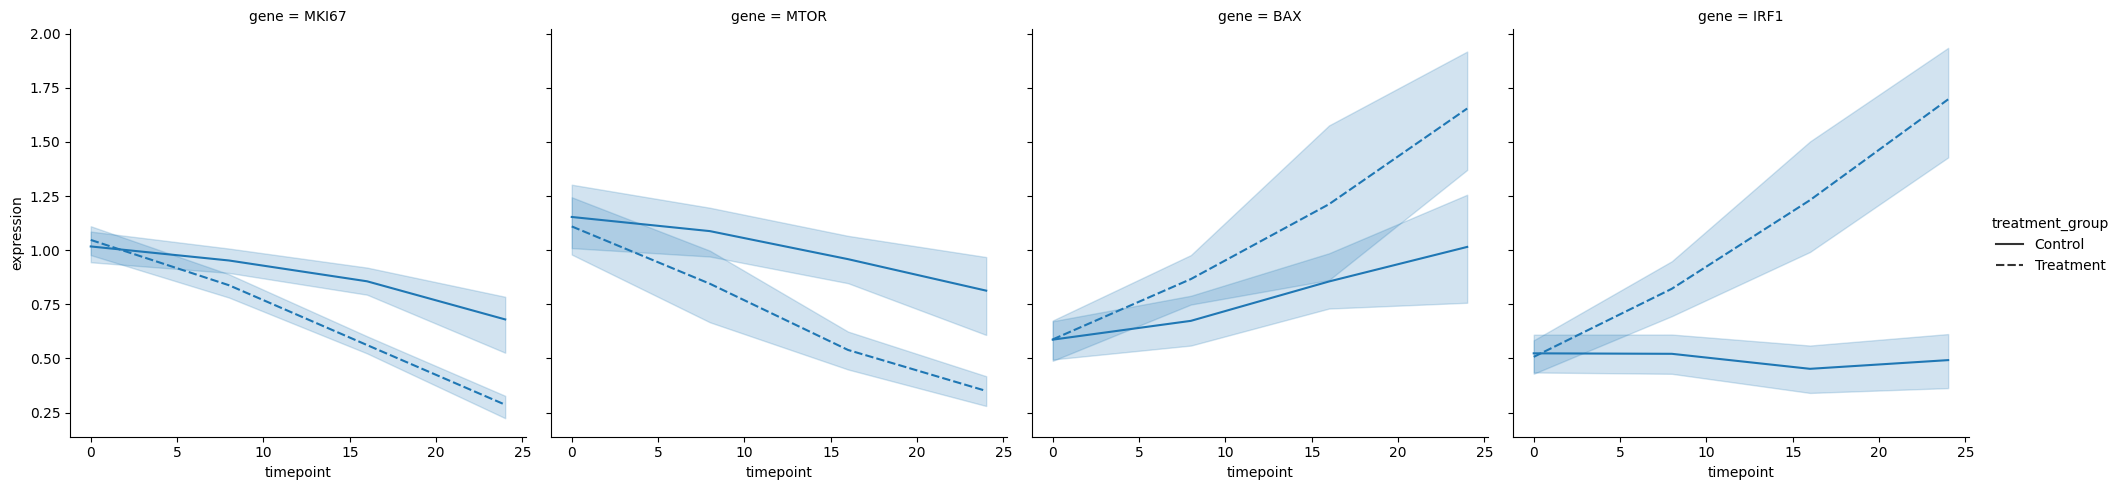

In [61]:
# relplot of expression over time
# style the line by treatment_group
# make a differnt plot for each gene
# make the type/kind "line"
sns.relplot(
    x="timepoint", y="expression", data=df_long, 
    style="treatment_group", col="gene", 
    kind="line"
)

**Exercise:** Let's practice making a new `relplot`, splitting the data in a different way.
* Plot expression over time for all genes
* Plot each `treatment_group` in a different plot area
* Color by `gene`

You should end up with 2 plots with 4 lines each.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

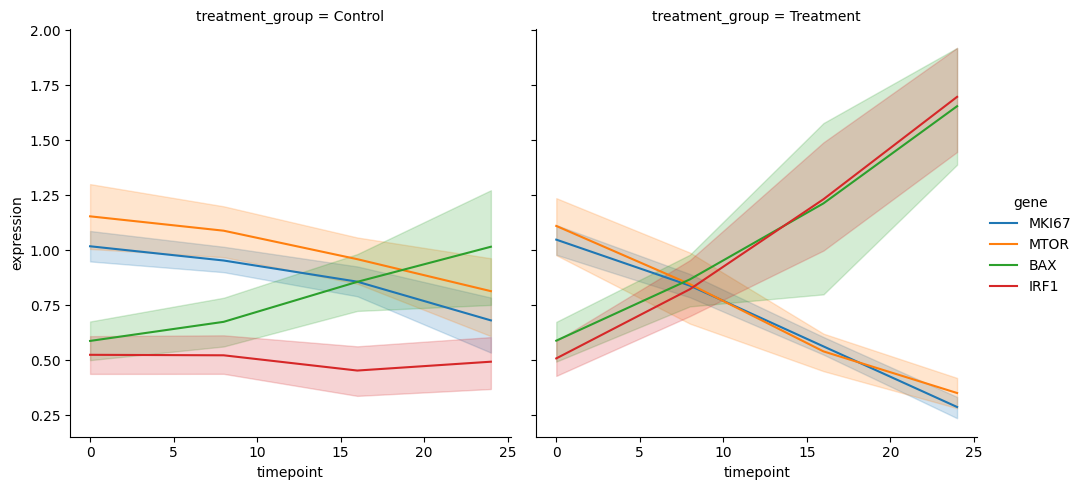

In [62]:
# relplot of expression over time
# color the line by gene
# make a differnt plot for each treatment_group
# make the type/kind "line"
sns.relplot(
    x="timepoint", y="expression", data=df_long, 
    hue="gene", col="treatment_group", 
    kind="line"
)

## Customization

The plots we've been making so far are great, but the labels on them look a little messy or aren't very informative. Let's make some changes.

First, let's go back to our very first line plot, plotting `BAX` expression over time and change the title. For this plot, let's go back to using our "wide" format data frame.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


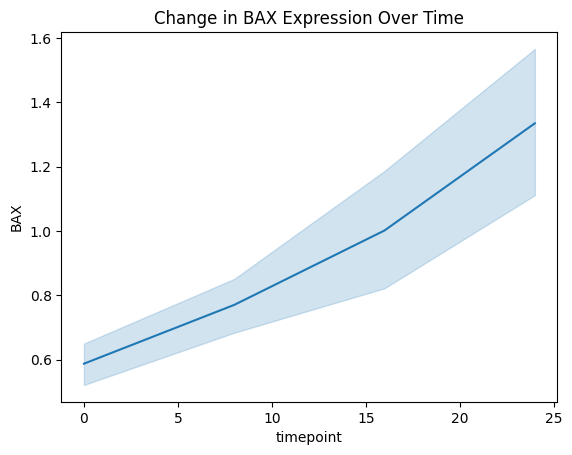

In [79]:
# Plot BAX expression over time using the df data frame
bax_line = sns.lineplot(x="timepoint", y="BAX", data=df)

# Set the title of this plot to "Change in BAX Expression Over Time"
bax_line.set_title("Change in BAX Expression Over Time")

# show the plot
plt.show()

Let's also change the labels on the x and y axis to be a little more informative. We can use the `seaborn` methods `set_xlabel` and `set_ylabel` for this.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


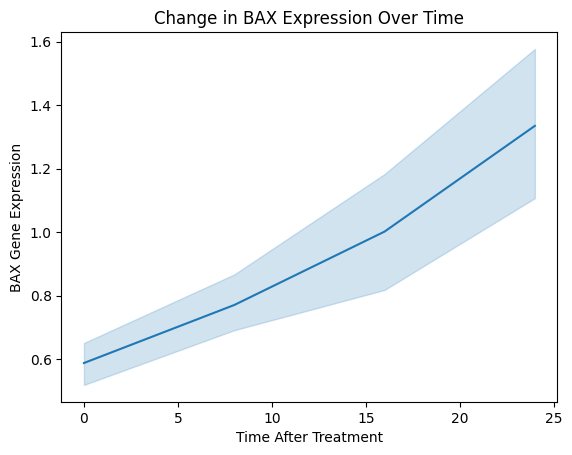

In [80]:
# Plot BAX expression over time using the df data frame
bax_line = sns.lineplot(x="timepoint", y="BAX", data=df)

# Set the title of this plot to "Change in BAX Expression Over Time"
bax_line.set_title("Change in BAX Expression Over Time")

# Set the x-axis label to "Time After Treatment"
bax_line.set_xlabel("Time After Treatment")

# Set the y-axis label to "BAX Gene Expression"
bax_line.set_ylabel("BAX Gene Expression")

# show the plot
plt.show()

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

AttributeError: 'FacetGrid' object has no attribute 'set_xlabel'

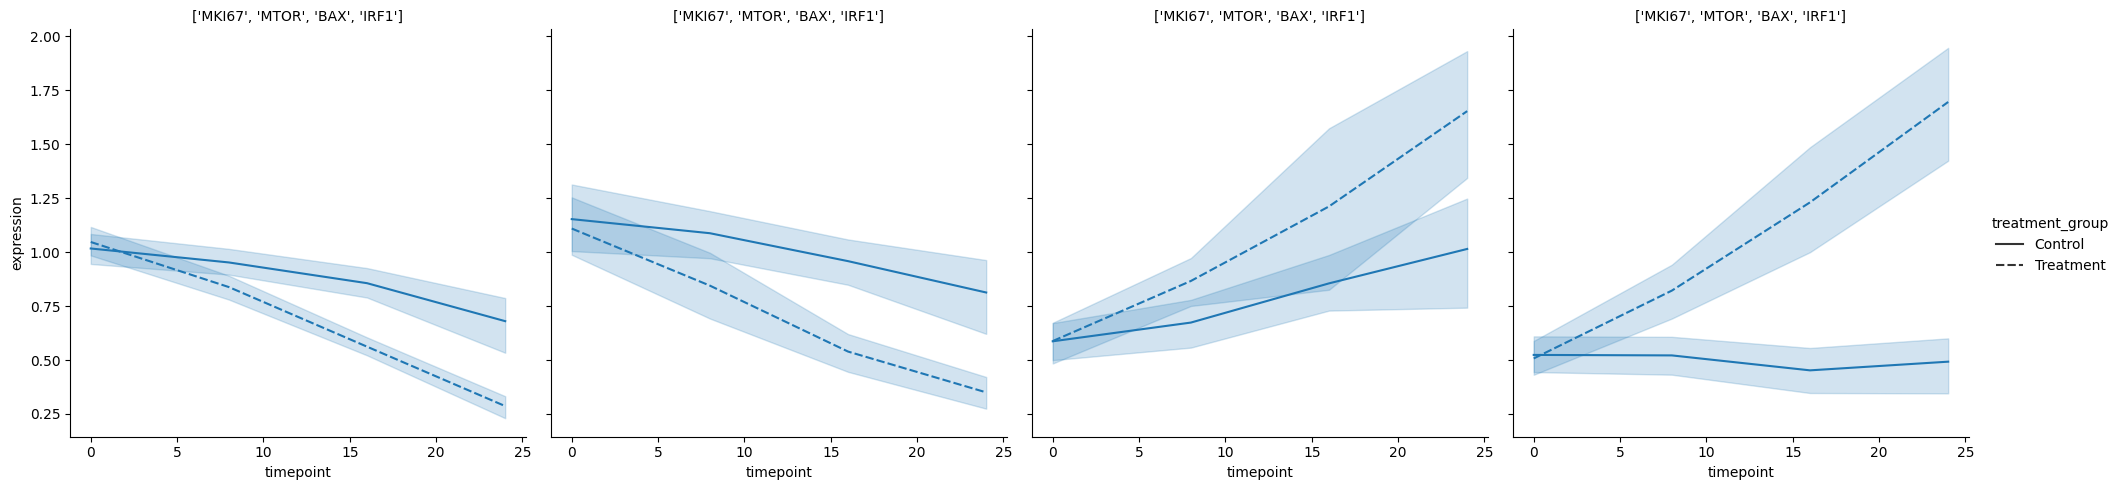

In [83]:
all_genes_line = sns.relplot(
    x="timepoint", y="expression", data=df_long, 
    style="treatment_group", col="gene", 
    kind="line"
)

# Set the title of this plot to "Change in BAX Expression Over Time"
all_genes_line.set_titles(["MKI67", "MTOR", "BAX", "IRF1"])

# Set the x-axis label to "Time After Treatment"
all_genes_line.set_xlabel("Time After Treatment")

# Set the y-axis label to "BAX Gene Expression"
all_genes_line.set_ylabel("BAX Gene Expression")

# show the plot
plt.show()